# NYC Spatial Analysis with GeoPandas

**Lesson 2.5 — Python Analysis**

This notebook loads the same NYC datasets from Lesson 2.2 (neighborhoods and fire hydrants),
explores them with GeoPandas, performs spatial analysis, and exports the results.

**What you'll learn:**
- Loading GeoJSON into GeoDataFrames
- Inspecting geometry types, CRS, and basic statistics
- Plotting spatial data with matplotlib
- Spatial joins (points in polygons)
- Exporting results to GeoParquet

## 1. Setup and Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Display all columns in DataFrames
pd.set_option('display.max_columns', None)

print(f"GeoPandas version: {gpd.__version__}")

GeoPandas version: 1.1.3


## 2. Load NYC Neighborhoods

We load the Neighborhood Tabulation Areas (NTAs) GeoJSON that was downloaded in Lesson 2.2.

In [2]:
neighborhoods = gpd.read_file("../2.2-postgis-setup/data/nyc_neighborhoods.geojson")

print(f"Shape: {neighborhoods.shape}")
print(f"CRS:   {neighborhoods.crs}")
print(f"Geometry type(s): {neighborhoods.geom_type.unique()}")
neighborhoods.head()

Shape: (262, 12)
CRS:   EPSG:4326
Geometry type(s): <ArrowStringArray>
['MultiPolygon']
Length: 1, dtype: str


ERROR 1: PROJ: proj_create_from_database: Open of /home/adria/projects/accelerator-2/part2-languages/2.5-python-analysis/.pixi/envs/default/share/proj failed


,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,geometry
0,35321808.4385,Greenpoint,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.5607283,Brooklyn,0,BK0101,3,047,Grnpt,BK01,"MULTIPOLYGON (((-73.93213 40.72816, -73.93238 ..."
1,28852852.8918,Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28134.0830277,Brooklyn,0,BK0102,3,047,Wllmsbrg,BK01,"MULTIPOLYGON (((-73.95814 40.7244, -73.95772 4..."
2,15208960.645,South Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.2800908,Brooklyn,0,BK0103,3,047,SWllmsbrg,BK01,"MULTIPOLYGON (((-73.95024 40.70547, -73.94984 ..."
3,52267406.735,East Williamsburg,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.8003755,Brooklyn,0,BK0104,3,047,EWllmsbrg,BK01,"MULTIPOLYGON (((-73.92406 40.71411, -73.92404 ..."
4,9982022.78755,Brooklyn Heights,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.1922849,Brooklyn,0,BK0201,3,047,BkHts,BK02,"MULTIPOLYGON (((-73.99236 40.68969, -73.99436 ..."


## 3. Load NYC Fire Hydrants

The hydrants dataset has ~110K point features. GeoPandas handles this just fine.

In [3]:
hydrants = gpd.read_file("../2.2-postgis-setup/data/nyc_hydrants.geojson")

print(f"Shape: {hydrants.shape}")
print(f"CRS:   {hydrants.crs}")
print(f"Geometry type(s): {hydrants.geom_type.unique()}")
hydrants.head()

Shape: (109725, 8)
CRS:   EPSG:4326
Geometry type(s): <ArrowStringArray>
['Point']
Length: 1, dtype: str


,cb,latitude,unitid,point_y,longitude,point_x,boro,geometry
0,407,40.7722168,H425919a,220683.273,-73.79457092,1041150.586,4,POINT (-73.79457 40.77222)
1,318,40.64434814,H325449,174041.245,-73.9128952,1008423.396,3,POINT (-73.91289 40.64435)
2,301,40.72505569,H307276,203437.906,-73.95304108,997266.219,3,POINT (-73.95304 40.72506)
3,302,40.6939888,H301843,192115.373,-73.99462891,985738.421,3,POINT (-73.99463 40.69399)
4,402,40.73529053,H439410,207168.6435,-73.93569183,1002071.97,4,POINT (-73.93569 40.73529)


## 4. Explore the Neighborhoods Data

Let's look at the columns, data types, and a summary of the borough breakdown.

In [4]:
print("Columns:")
print(neighborhoods.dtypes)
print()
print("Neighborhoods per borough:")
print(neighborhoods['boroname'].value_counts())

Columns:
shape_area         str
ntaname            str
cdtaname           str
shape_leng         str
boroname           str
ntatype            str
nta2020            str
borocode           str
countyfips         str
ntaabbrev          str
cdta2020           str
geometry      geometry
dtype: object

Neighborhoods per borough:
boroname
Queens           82
Brooklyn         69
Bronx            50
Manhattan        38
Staten Island    23
Name: count, dtype: int64


## 5. Plot the Neighborhoods

A quick map to confirm the data looks right — you should see the five boroughs of NYC.

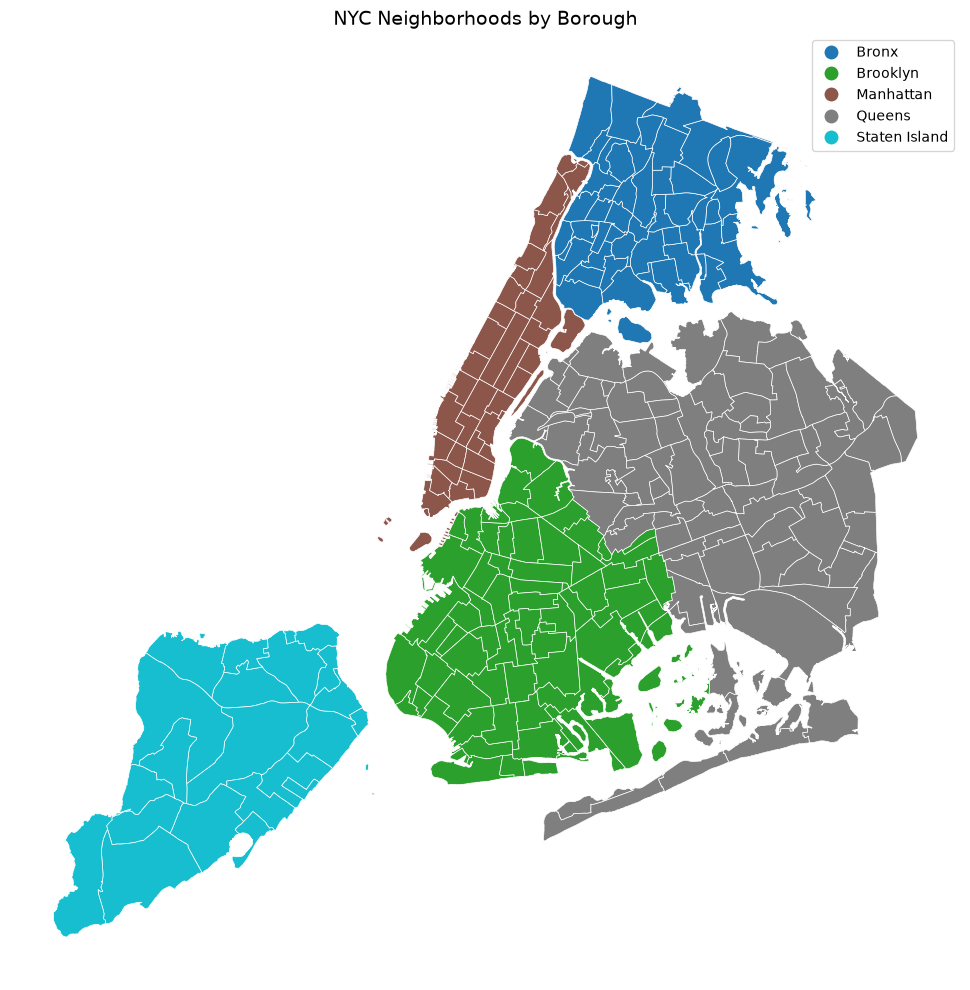

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

neighborhoods.plot(
    ax=ax,
    column='boroname',
    legend=True,
    edgecolor='white',
    linewidth=0.5,
)

ax.set_title('NYC Neighborhoods by Borough', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Plot a Sample of Hydrants

Plotting all 110K points is slow, so we take a random sample of 5,000
and overlay them on the neighborhood boundaries.

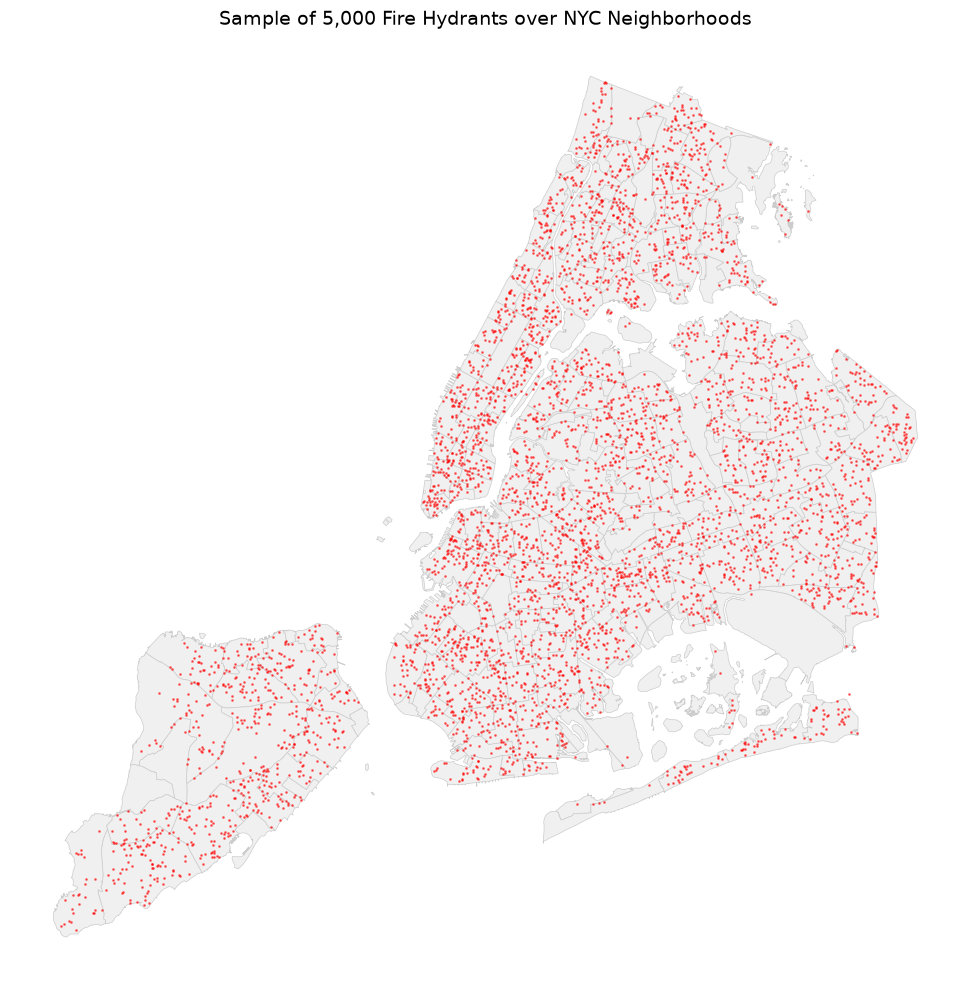

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Draw neighborhood outlines as the basemap
neighborhoods.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)

# Overlay a sample of hydrants
hydrants.sample(5000, random_state=42).plot(
    ax=ax,
    color='red',
    markersize=1,
    alpha=0.5,
)

ax.set_title('Sample of 5,000 Fire Hydrants over NYC Neighborhoods', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 7. Spatial Join — Count Hydrants per Neighborhood

This is the core spatial analysis: for each hydrant, find which neighborhood it falls in.
We use `sjoin` (spatial join) with `predicate='within'`.

This may take 30–60 seconds on ~110K points against ~260 polygons.

In [7]:
# Spatial join: tag each hydrant with the neighborhood it falls within
hydrants_with_nta = gpd.sjoin(
    hydrants,
    neighborhoods[['ntaname', 'boroname', 'geometry']],
    how='inner',
    predicate='within',
)

print(f"Hydrants matched to a neighborhood: {len(hydrants_with_nta):,}")
print(f"Hydrants NOT matched (outside boundaries): {len(hydrants) - len(hydrants_with_nta):,}")
hydrants_with_nta.head()

Hydrants matched to a neighborhood: 109,694
Hydrants NOT matched (outside boundaries): 31


,cb,latitude,unitid,point_y,longitude,point_x,boro,geometry,index_right,ntaname,boroname
0,407,40.7722168,H425919a,220683.273,-73.79457092,1041150.586,4,POINT (-73.79457 40.77222),210,Auburndale,Queens
1,318,40.64434814,H325449,174041.245,-73.9128952,1008423.396,3,POINT (-73.91289 40.64435),61,Canarsie,Brooklyn
2,301,40.72505569,H307276,203437.906,-73.95304108,997266.219,3,POINT (-73.95304 40.72506),0,Greenpoint,Brooklyn
3,302,40.6939888,H301843,192115.373,-73.99462891,985738.421,3,POINT (-73.99463 40.69399),4,Brooklyn Heights,Brooklyn
4,402,40.73529053,H439410,207168.6435,-73.93569183,1002071.97,4,POINT (-73.93569 40.73529),166,Sunnyside,Queens


## 8. Hydrant Counts by Neighborhood

Group by neighborhood name, count, and sort to find the most hydrant-dense areas.

In [8]:
hydrant_counts = (
    hydrants_with_nta
    .groupby(['ntaname', 'boroname'])
    .size()
    .reset_index(name='hydrant_count')
    .sort_values('hydrant_count', ascending=False)
)

print("Top 10 neighborhoods by hydrant count:")
print(hydrant_counts.head(10).to_string(index=False))

print(f"\nTotal neighborhoods with hydrants: {len(hydrant_counts)}")

Top 10 neighborhoods by hydrant count:
                                             ntaname      boroname  hydrant_count
              Annadale-Huguenot-Prince's Bay-Woodrow Staten Island           1708
                             Great Kills-Eltingville Staten Island           1672
Todt Hill-Emerson Hill-Lighthouse Hill-Manor Heights Staten Island           1282
      Sheepshead Bay-Manhattan Beach-Gerritsen Beach      Brooklyn           1187
                                            Canarsie      Brooklyn           1155
                       Westerleigh-Castleton Corners Staten Island           1137
       New Springville-Willowbrook-Bulls Head-Travis Staten Island           1111
           West New Brighton-Silver Lake-Grymes Hill Staten Island           1103
                                           Bay Ridge      Brooklyn           1096
                                          St. Albans        Queens           1086

Total neighborhoods with hydrants: 259


## 9. Choropleth Map — Hydrant Density by Neighborhood

Merge the counts back to the neighborhood polygons and visualize.

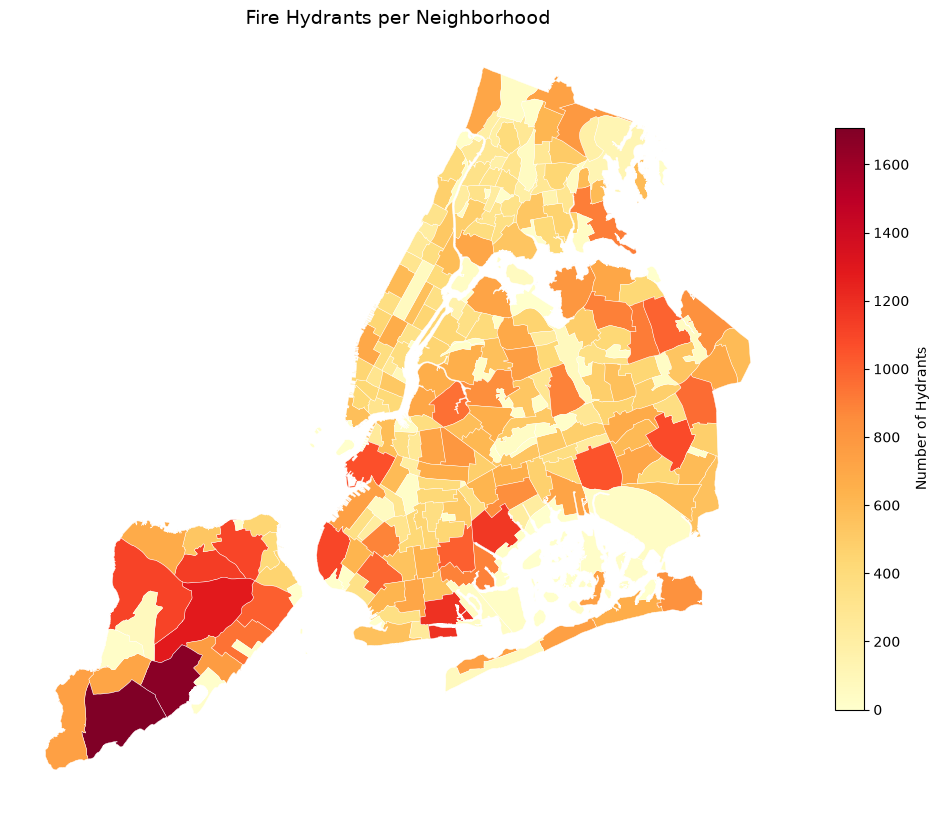

In [9]:
# Merge counts onto the neighborhood geometries
neighborhoods_with_counts = neighborhoods.merge(
    hydrant_counts[['ntaname', 'hydrant_count']],
    on='ntaname',
    how='left',
)

# Fill neighborhoods with no hydrants as 0
neighborhoods_with_counts['hydrant_count'] = (
    neighborhoods_with_counts['hydrant_count'].fillna(0).astype(int)
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

neighborhoods_with_counts.plot(
    ax=ax,
    column='hydrant_count',
    cmap='YlOrRd',
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    legend_kwds={'label': 'Number of Hydrants', 'shrink': 0.6},
)

ax.set_title('Fire Hydrants per Neighborhood', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 10. Calculate Hydrant Density (per km²)

Raw counts are misleading — large neighborhoods naturally have more hydrants.
We reproject to a meter-based CRS (EPSG:3857) to calculate area, then compute density.

In [10]:
# Reproject to Web Mercator for area calculation in meters
neighborhoods_projected = neighborhoods_with_counts.to_crs(epsg=3857)

# Calculate area in square kilometers
neighborhoods_with_counts['area_km2'] = neighborhoods_projected.geometry.area / 1_000_000

# Hydrants per square kilometer
neighborhoods_with_counts['hydrants_per_km2'] = (
    neighborhoods_with_counts['hydrant_count'] / neighborhoods_with_counts['area_km2']
).round(1)

# Top 10 densest neighborhoods
densest = neighborhoods_with_counts.nlargest(10, 'hydrants_per_km2')
print("Top 10 neighborhoods by hydrant density (per km²):")
print(densest[['ntaname', 'boroname', 'hydrant_count', 'area_km2', 'hydrants_per_km2']]
      .to_string(index=False))

Top 10 neighborhoods by hydrant density (per km²):
                             ntaname  boroname  hydrant_count  area_km2  hydrants_per_km2
                            Gramercy Manhattan            269  1.219057             220.7
     SoHo-Little Italy-Hudson Square Manhattan            432  2.091418             206.6
                Tribeca-Civic Center Manhattan            433  2.198115             197.0
                        West Village Manhattan            447  2.335094             191.4
Financial District-Battery Park City Manhattan            570  3.111662             183.2
                   Greenwich Village Manhattan            304  1.717140             177.0
       Upper East Side-Carnegie Hill Manhattan            565  3.253863             173.6
                        East Village Manhattan            522  3.073390             169.8
                Midtown-Times Square Manhattan            669  3.979502             168.1
               Chinatown-Two Bridges Manhattan   

## 11. Export Results to GeoParquet

GeoParquet is a modern, efficient format for geospatial data — much faster to read
than Shapefiles or GeoJSON, and it preserves CRS metadata.

In [ ]:
output_path = 'nyc_neighborhood_hydrant_density.parquet'

neighborhoods_with_counts.to_parquet(output_path)

# Verify the export by reading it back
result = gpd.read_parquet(output_path)
print(f"Exported to: {output_path}")
print(f"Shape: {result.shape}")
print(f"CRS:   {result.crs}")
print(f"Columns: {list(result.columns)}")

Exported to: nyc_neighborhood_hydrant_density.parquet
Shape: (262, 15)
CRS:   {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbrev

## Summary

In this notebook you:

1. Loaded two GeoJSON datasets into GeoDataFrames
2. Explored geometry types, CRS, and column structures
3. Plotted neighborhoods and hydrants with matplotlib
4. Performed a spatial join to count hydrants per neighborhood
5. Calculated area-normalized hydrant density
6. Exported the results to GeoParquet

These same patterns — load, explore, spatial join, aggregate, export — apply to
almost any point-in-polygon analysis.